# Gradient Domain Editing

## 📦 Packages

In [2]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

import numpy as np
import cv2
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

import scipy

## 🚙 Utilities

In [3]:
def show(i, title: str = "Color Image"):
    t = "gray" if i.ndim == 2 else "color"
    
    if t == "color":
        # color
        plt.imshow(cv2.cvtColor(src=i, code=cv2.COLOR_BGR2RGB))
        plt.title(t)
        plt.axis("off")
        plt.show()
    else:
        # gray
        plt.imshow(i, cmap="gray")
        plt.title(t)
        plt.axis("off")
        plt.show()
    

def side2side(i1, i2):
    plt.figure(figsize=(10, 5))
    
    t1 = "gray" if i1.ndim == 2 else "color"
    t2 = "gray" if i2.ndim == 2 else "color"
    
    # color/gray
    plt.subplot(1, 2, 1)
    plt.title(t1)
    if t1 == "gray":
        plt.imshow(X=i1, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(X=cv2.cvtColor(i1, code=cv2.COLOR_BGR2RGB))
    plt.axis("off")
    
    
    # color/gray
    plt.subplot(1, 2, 2)
    plt.title(t2)
    if t2 == "gray":
        plt.imshow(X=i2, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(X=cv2.cvtColor(i2, code=cv2.COLOR_BGR2RGB))
    plt.axis("off")
    

def store(image, file):
    cv2.imwrite(filename=file, img=image)
    

def use_this_to_determine_the_mask_region(image):
    cv2.namedWindow(winname="Use this to determine the region for mask", flags=cv2.WINDOW_NORMAL)
    cv2.imshow(winname="Use this to determine the region for mask", mat=image)
    cv2.waitKey(-1)
    cv2.destroyAllWindows()

## 🧑‍💻 Codes

### 🖼️ Images

#### Path

In [4]:
input_path = Path("..") / "data" / "input"
output_path = Path("..") / "data" / "output"

In [5]:
sudoku_path = Path("..") / "data" / "input" / "sudoku.jpg"

In [6]:
eye_path = Path("..") / "data" / "input" / "eye_of_providence.webp"
pyramid_path = Path("..") / "data" / "input" / "pyramid.jpg"
falcon_path = Path("..") / "data" / "input" / "millennium_falcon.webp"

window_xp_path = input_path / "window_xp.jpg"
my_cat_path = input_path / "my_cat.jpg"

In [7]:
kyoto_path = input_path / "kyoto.webp"
gojira_path = input_path / "gojira.jpg"
nagoyajou_path = input_path / "nagoyajou.jpg"
mosura_path = input_path / "mosura.jpg"

In [43]:
chess_path = input_path / "chess_board.jpg"

#### Images

In [58]:
sudoku = cv2.imread(filename=sudoku_path.as_posix())
sudoku = cv2.cvtColor(sudoku, cv2.COLOR_BGR2GRAY)

eye = cv2.imread(eye_path)
# eye = cv2.cvtColor(eye, cv2.COLOR_BGR2GRAY)
eye = cv2.resize(eye, dsize=(200, 200))

pyramid = cv2.imread(pyramid_path)
# pyramid = cv2.cvtColor(pyramid, cv2.COLOR_BGR2GRAY)
pyramid = cv2.resize(pyramid, dsize=(500, 500))

falcon = cv2.imread(falcon_path)
falcon = cv2.resize(falcon, dsize=(200, 150))

windowXp = cv2.imread(window_xp_path)
windowXp = cv2.resize(windowXp, dsize=(1920, 1080))
my_cat = cv2.imread(my_cat_path)
my_cat = cv2.resize(my_cat, dsize=(500, 700))

kyoto = cv2.imread(kyoto_path)
kyoto = cv2.cvtColor(kyoto, cv2.COLOR_BGR2GRAY)

gojira = cv2.imread(gojira_path)
gojira = cv2.cvtColor(gojira, cv2.COLOR_BGR2GRAY)
gojira = cv2.resize(gojira, dsize=(600, 600))
gojira_= cv2.cvtColor(gojira, cv2.COLOR_GRAY2BGR)

nagoyajou = cv2.imread(nagoyajou_path)
nagoyajou = cv2.cvtColor(nagoyajou, cv2.COLOR_BGR2GRAY)
nagoyajou_ = cv2.cvtColor(nagoyajou, cv2.COLOR_GRAY2BGR)

mosura = cv2.imread(mosura_path)
mosura = cv2.cvtColor(mosura, cv2.COLOR_BGR2GRAY)
mosura_ = cv2.cvtColor(mosura, cv2.COLOR_GRAY2BGR)

chess_board = cv2.imread(chess_path)

In [9]:
nagoyajou.shape

(900, 1450)

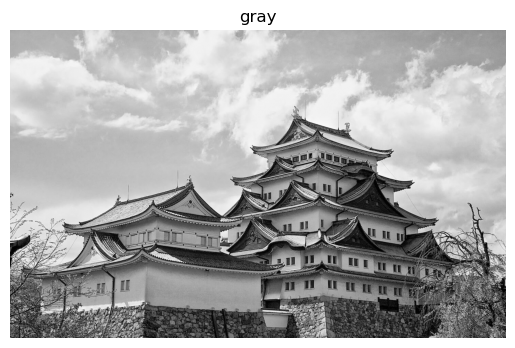

In [10]:
show(nagoyajou)

In [11]:
gojira.shape

(600, 600)

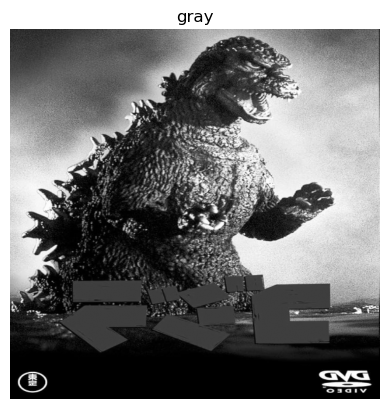

In [12]:
show(gojira)

In [13]:
mosura.shape

(350, 700)

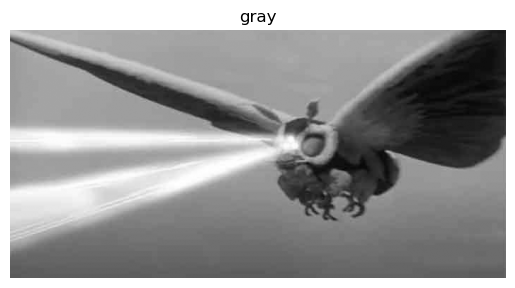

In [14]:
show(mosura)

In [15]:
# width: 110 -> 180 // 70
# height: 110 -> 180 // 70
# center = 150

# mask x: 60 -> 140
#      y: 40 -> 110
use_this_to_determine_the_mask_region(nagoyajou_)

### 🤡 Understand Laplacian

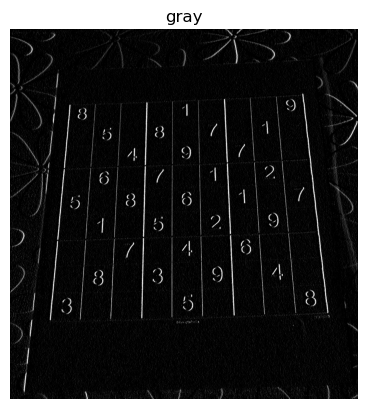

In [16]:
sudoku_sobel_x = cv2.Sobel(sudoku, ddepth=-1, dx=1, dy=0)

show(sudoku_sobel_x)

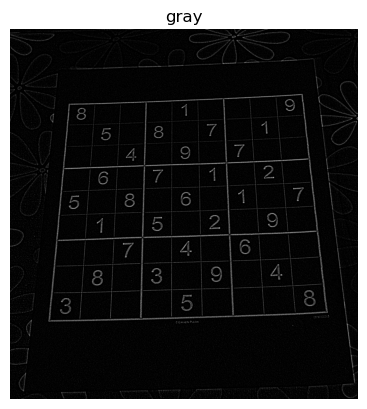

In [17]:
sudoku_gaussion = cv2.GaussianBlur(sudoku, (5, 5), 0)
sudoku_laplacian = cv2.Laplacian(sudoku_gaussion, ddepth=-1)
sudoku_laplacian = cv2.convertScaleAbs(sudoku_laplacian, dst=-1)

show(sudoku_laplacian, title="Laplacian filter")

### 🌀 Seamless cloning

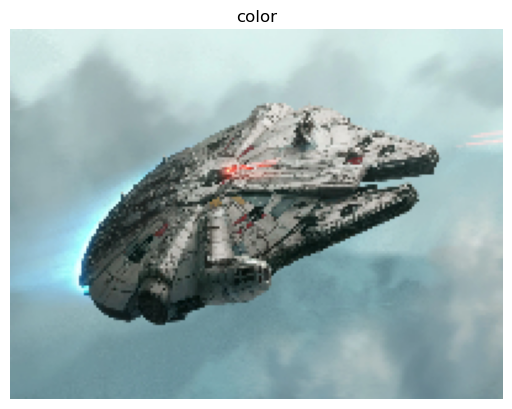

In [18]:
show(falcon)

In [19]:
mask_eye = np.zeros(shape=eye.shape[:2], dtype=np.uint8)

mask_eye[20:160, 50:160] = 255

center = (250, 250)

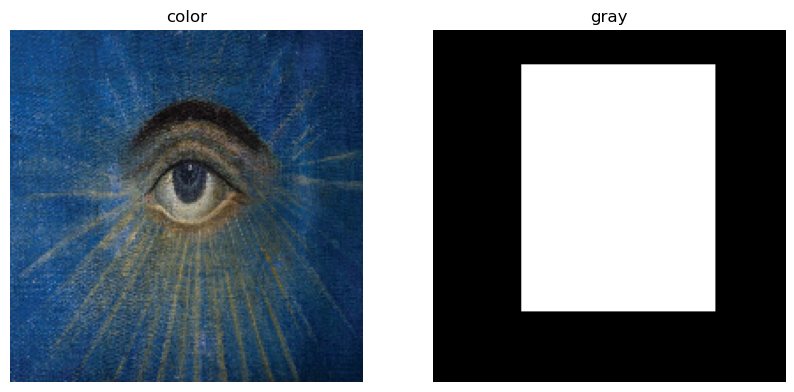

In [20]:
side2side(eye, mask_eye)

In [21]:
seamless_cloning_result_1 = cv2.seamlessClone(eye, pyramid, mask_eye, center, cv2.NORMAL_CLONE)

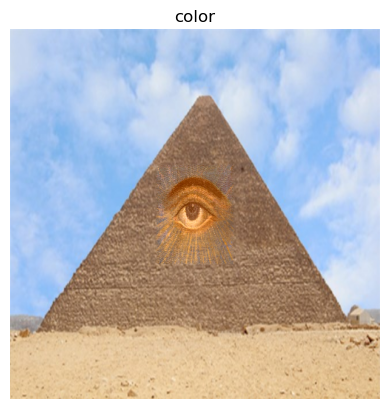

In [22]:
show(seamless_cloning_result_1, title="Eye of providence")

In [23]:
mask_falcon = np.zeros(shape=falcon.shape[:2], dtype=np.uint8)

points = np.array(
    [
        [97, 20],
        [35, 62],
        [5, 128],
        [113, 124],
        [172, 87],
        [192, 24]
    ]
)

mask_falcon = cv2.fillPoly(mask_falcon, [points], 255)

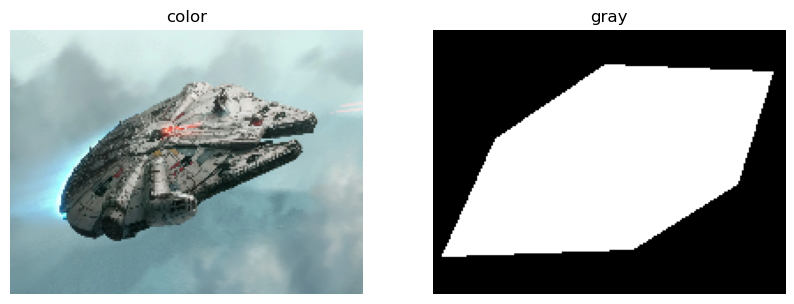

In [24]:
side2side(falcon, mask_falcon)

In [25]:
seamless_cloning_result_2 = cv2.seamlessClone(falcon, seamless_cloning_result_1, mask_falcon, (100, 75), cv2.NORMAL_CLONE)

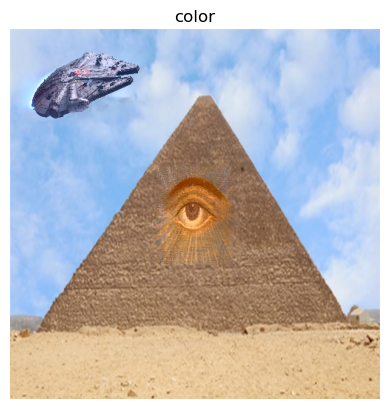

In [26]:
show(seamless_cloning_result_2)

In [27]:
store(seamless_cloning_result_2, output_path / "1.png")

### 🌀 Seamless cloning (cont.)

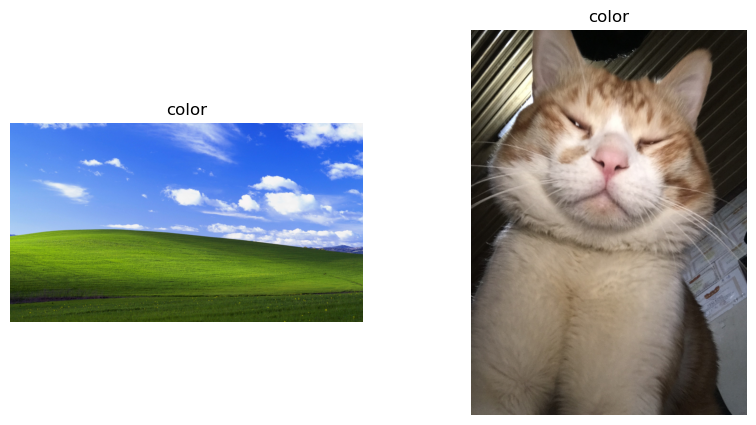

In [28]:
side2side(windowXp, my_cat)

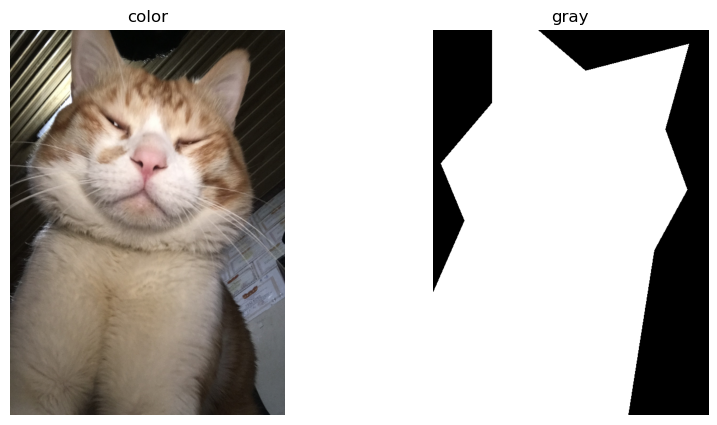

In [29]:
mask_cat = np.zeros(shape=my_cat.shape[:2], dtype=np.uint8)

points = np.array(
    [
        [107, 0],
        [107, 132],
        [14, 242],
        [57, 346],
        [0, 477],
        [0, 700],
        [353, 700],
        [400, 400],
        [460, 290],
        [420, 180],
        [463, 25],
        [276, 74],
        [190, 0]
    ]
)

mask_cat = cv2.fillPoly(img=mask_cat, pts=[points], color=255)

side2side(my_cat, mask_cat)

In [30]:
windowXo_my_cat = cv2.seamlessClone(src=my_cat, dst=windowXp, mask=mask_cat, p=(1400,350), flags=cv2.NORMAL_CLONE)

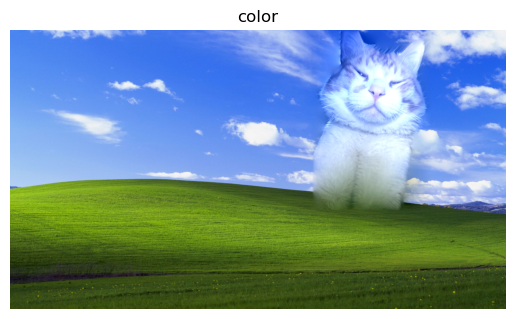

In [31]:
show(windowXo_my_cat)

In [32]:
store(windowXo_my_cat, output_path / "2.png")

### 🌀 Seamless cloning (Manual)

In [33]:
# for computation / not causing overflow
nagoyajou = nagoyajou.astype(np.float64)
gojira = gojira.astype(np.float64)
mosura = mosura.astype(np.float64)

#### 👺 For comparison

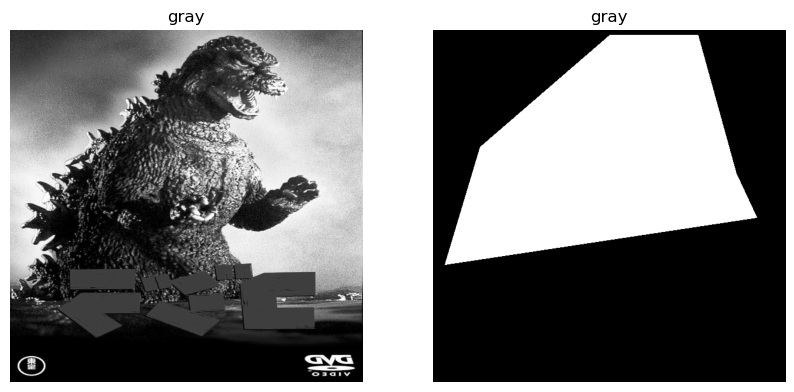

In [34]:
gojira_mask = np.zeros(shape=gojira.shape, dtype=np.uint8)

points = np.array([
    [20, 400],
    [550, 320],
    [515, 245],
    [450, 10],
    [300, 10],
    [80, 200]
])

gojira_mask = cv2.fillPoly(img=gojira_mask, pts=[points], color=255)

side2side(gojira, gojira_mask)

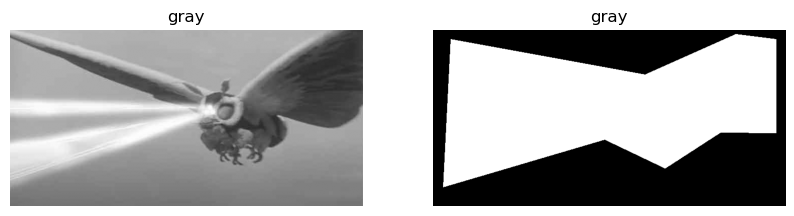

In [35]:
mosura_mask = np.zeros(shape=mosura.shape, dtype=np.uint8)

points = np.array(
    [
        [35, 20],
        [420, 90],
        [600, 10],
        [700 - 20, 20],
        [700 - 20, 205],
        [570, 204],
        [460, 275],
        [340, 218],
        [20, 312]   
    ]
)

mosura_mask = cv2.fillPoly(mosura_mask, pts=[points], color=255)
side2side(mosura, mosura_mask)

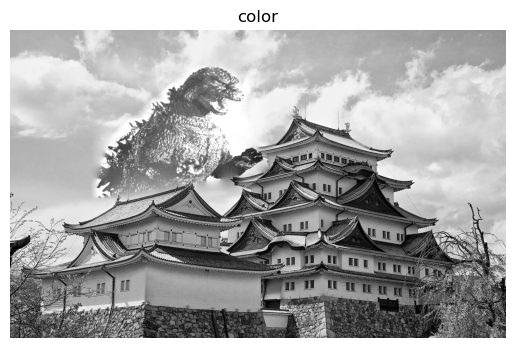

In [36]:
gojira_attack_nagoyajou = cv2.seamlessClone(gojira_, dst=nagoyajou_, mask=gojira_mask.copy(), p=(500, 300), flags=cv2.NORMAL_CLONE)
show(gojira_attack_nagoyajou)

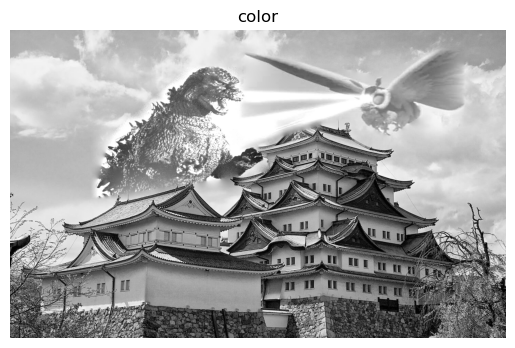

In [37]:
gojira_attack_nagoyajou_with_mosura = cv2.seamlessClone(mosura_, dst=gojira_attack_nagoyajou, mask=mosura_mask.copy(), flags=cv2.NORMAL_CLONE, p=(1000, 200))
show(gojira_attack_nagoyajou_with_mosura)

#### 🦽 Manual implementation

- Make the gradient inside the pasted regions follow the source
- Make the gradient at the boundary to follow the destination
- Gradient of the pasted image == gradient of the source image
- Minimize that leads to the discrete Poisson Equation
- Poisson equation:
  - $$\Delta v = \Delta S$$
  - Laplacian of the unknown image = Laplacian of the source image
  - With v = T (on boundary: target image)
- We will convert each pixel into an equation
- If the neighbour is outside the mask, we will use the pixel data of the target

O ------------------> x
|
|
|
|
|
v
y

In [38]:
# Used to index the neighbours pixels, we are using (y, x) y = row, x = column
# (height, width, channel)
UP =    (-1, 0)
DOWN =  (+1, 0)
LEFT =  (0, -1)
RIGHT = (0, +1)

DIRECTIONS = [
    UP,
    DOWN,
    LEFT,
    RIGHT
]

In [39]:
def seamless_clone(source, mask, target, place):
    # 1️⃣ Index mapping
    h, w = source.shape

    pixel_index = {}
    idx = 0

    for y in range(h):
        for x in range(w):
            # map (y, x) into index
            # for solving the linear equation system
            # Laplacian v = Laplacian x
            if mask[y, x] > 0:
                pixel_index[(y, x)] = idx
                idx+=1
            # v = [v_0, v_1, v_2, ..., v_n]
            
    # total number of unknown pixel
    N = idx
    
    # 2️⃣ Matrix creation
    # useful for building/modifying but not for heavy mathematic operations
    A = lil_matrix((N, N))
    b = np.zeros(shape=(N, ))
    
    
    # 3️⃣ Fill the matrix values (which are the coefficients of the linear equation system)
    for (y, x), i in pixel_index.items():
        # for each pixel inside the mask
        # center coefficient
        A[i, i] = 4
        
        # for each neighbour
        for dy, dx in DIRECTIONS:
            ny = y + dy
            nx = x + dx
            
            # right-hand side constraint
            b[i] += source[y, x] - source[ny, nx]
            
            # Add the coefficient or the target
            if mask[ny, nx] > 0:
                # this neighbour is inside -> variables
                index = pixel_index[(ny, nx)]
                A[i, index] = -1
            else:
                # outside the mask
                # then we know that that values
                # should be the pixel values of the target
                b[i] += target[place[0] + ny, place[1] + nx]
    
    # solve the linear equation system
    A = A.tocsr()
    v = scipy.sparse.linalg.spsolve(A, b)
    # return v, pixel_index
    
    # 4️⃣ Reconstruct the image
    # (y, x) index of masked values / source coordinate
    # index is the index of the pixel values in v
    
    result = target.copy()
    for (y, x), index in pixel_index.items():
        result[place[0] + y, place[1] + x] = np.clip(v[index], 0, 255)
        
    return result

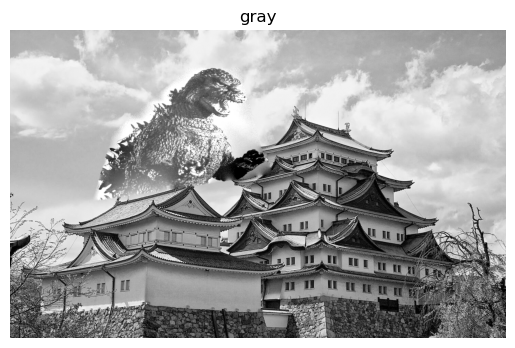

In [40]:
gojira_attack_nagoyajou_manual = seamless_clone(source=gojira, mask=gojira_mask, target=nagoyajou, place=(100, 220))
show(gojira_attack_nagoyajou_manual)

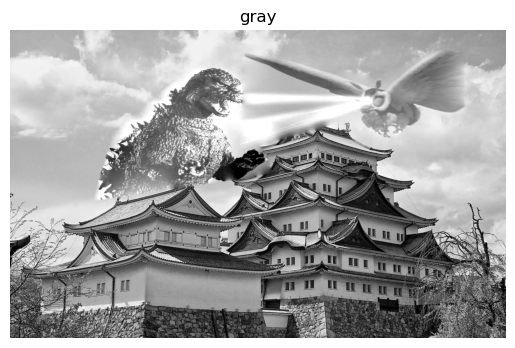

In [41]:
gojira_attack_nagoyajou_with_mosura_manual = seamless_clone(source=mosura, mask=mosura_mask, target=gojira_attack_nagoyajou_manual, place=(45, 650))
show(gojira_attack_nagoyajou_with_mosura_manual)

#### 🧑‍🤝‍🧑 Result comparison

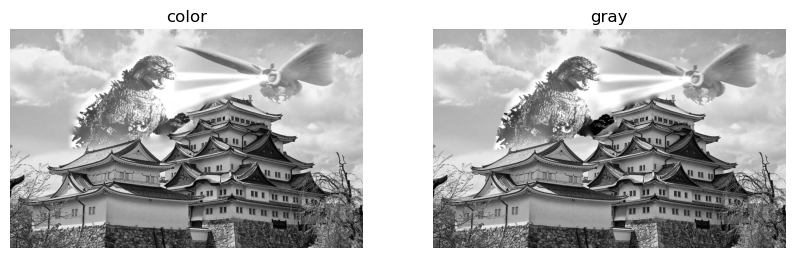

In [42]:
side2side(gojira_attack_nagoyajou_with_mosura, gojira_attack_nagoyajou_with_mosura_manual)

### 💱 Transformations

#### 1️⃣ Rigid transformation (Translation and Rotation)

In [60]:
chess_board.shape

(1000, 1000, 3)

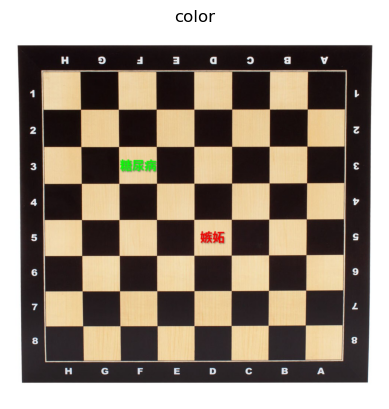

In [59]:
show(chess_board)

#### ➡️ Translation

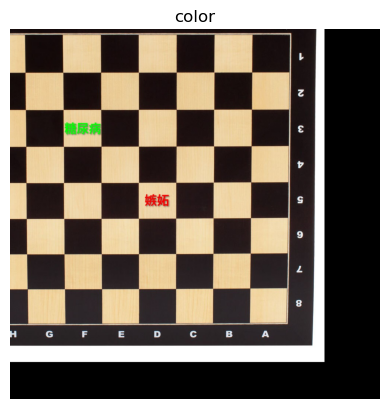

In [61]:
tx = -150 # Move to the left
ty = -100 # Move upwards

# Pixels having new coordinates based on the transformations

h, w, _ = chess_board.shape
# x
# y
# 1
TRANSLATION_MATRIX = np.float32(
    [
        [1, 0, tx],
        [0, 1, ty]
    ]
)

translated = cv2.warpAffine(chess_board, TRANSLATION_MATRIX, dsize=(h, w))
show(translated)

#### ⭕ Rotation

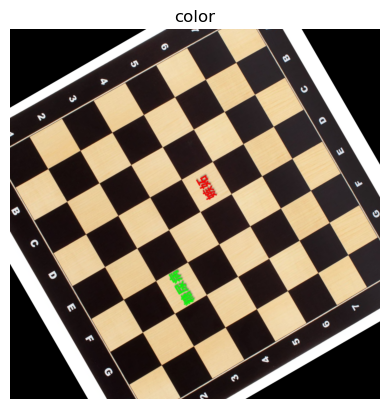

In [81]:
center = (h // 2, w // 2)
angle = 120
scale = 1.0

ROTATION_MATRIX = cv2.getRotationMatrix2D(center=center, angle=angle, scale=scale)

rotated = cv2.warpAffine(chess_board, ROTATION_MATRIX, dsize=(w, h))

show(rotated)

In [55]:
for i in range(360):
    rotated = cv2.warpAffine(
        chess_board,
        cv2.getRotationMatrix2D(center, i, scale=1),
        dsize=(w, h)
    )

    cv2.imshow("Rotation Animation", rotated)

    if cv2.waitKey(30) & 0xFF == 27:
        break

cv2.destroyAllWindows()

#### 2️⃣ Rigid transformation (Translation and Rotation)

#### 2️⃣ Rigid transformation (Translation and Rotation)

#### 2️⃣ Rigid transformation (Translation and Rotation)